<a href="https://colab.research.google.com/github/dokushin/GCI_comp2/blob/main/my_test2-7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

| カラム名 | 意味 |
|---|---|
| customer_id | 顧客ID（予測には使いません） |
| birth_year | 生まれ年 |
| education_level | 学歴 |
| marital_status | 配偶状況 |
| annual_income | 年収 |
| num_children | 子供の人数 |
| num_teenagers | ティーンエイジャーの人数 |
| registration_date | 顧客の登録日 |
| days_since_last_purchase | 最終購入からの経過日数 |
| spend_wines | ワインへの消費額 |
| spend_fruits | 果物への消費額 |
| spend_meat | 肉類への消費額 |
| spend_fish | 魚類への消費額 |
| spend_sweets | 菓子への消費額 |
| spend_gold | 金製品への消費額 |
| deals_purchases | 割引での購入回数 |
| web_purchases | Web サイト経由の購入回数 |
| catalog_purchases | カタログ経由の購入回数 |
| store_purchases | 実店舗での購入回数 |
| monthly_web_visits | 月あたりの Web サイト訪問回数 |
| has_complaint | 過去に苦情を申し立てたか（1=あり） |
| target | キャンペーンに反応したか（1=反応）。**これが予測対象です** |

`spend_` で始まる列は「その商品カテゴリにいくら使ったか」、`_purchases` で終わる列は「そのチャネルで何回買ったか」を表します。

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
!pip install japanize-matplotlib lightgbm xgboost optuna --quiet
!pip install category_encoders

In [92]:
# モジュールのインポート
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語表示用
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import optuna
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [93]:
PATH = '/content/drive/MyDrive/GCI/competition_2/'

In [94]:
train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
print('Train:', train.shape, ' Test:', test.shape)

Train: (1568, 22)  Test: (672, 21)


In [95]:
train.isnull().sum()

,0
customer_id,0
birth_year,0
education_level,0
marital_status,0
annual_income,15
num_children,0
num_teenagers,0
registration_date,0
days_since_last_purchase,0
spend_wines,0


In [96]:
test.isnull().sum()

,0
customer_id,0
birth_year,0
education_level,0
marital_status,0
annual_income,9
num_children,0
num_teenagers,0
registration_date,0
days_since_last_purchase,0
spend_wines,0


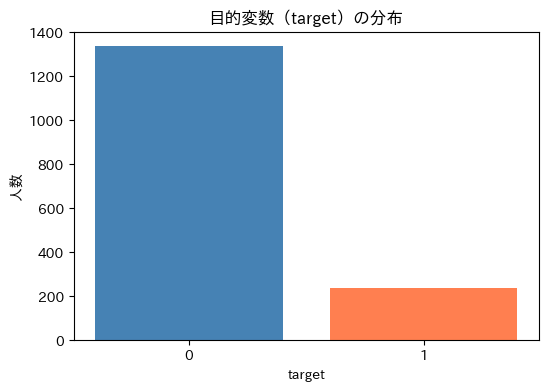

In [97]:
target_counts = train['target'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index.astype(str), target_counts.values, color=['steelblue', 'coral'])
plt.xlabel('target')
plt.ylabel('人数')
plt.title('目的変数（target）の分布')
plt.show()


In [98]:
target_pct = train['target'].value_counts(normalize=True) * 100
print(f"target=0(非反応):{target_pct[0]:.1f}%")
print(f"target=1(反応):{target_pct[1]:.1f}%")

target=0(非反応):85.1%
target=1(反応):14.9%


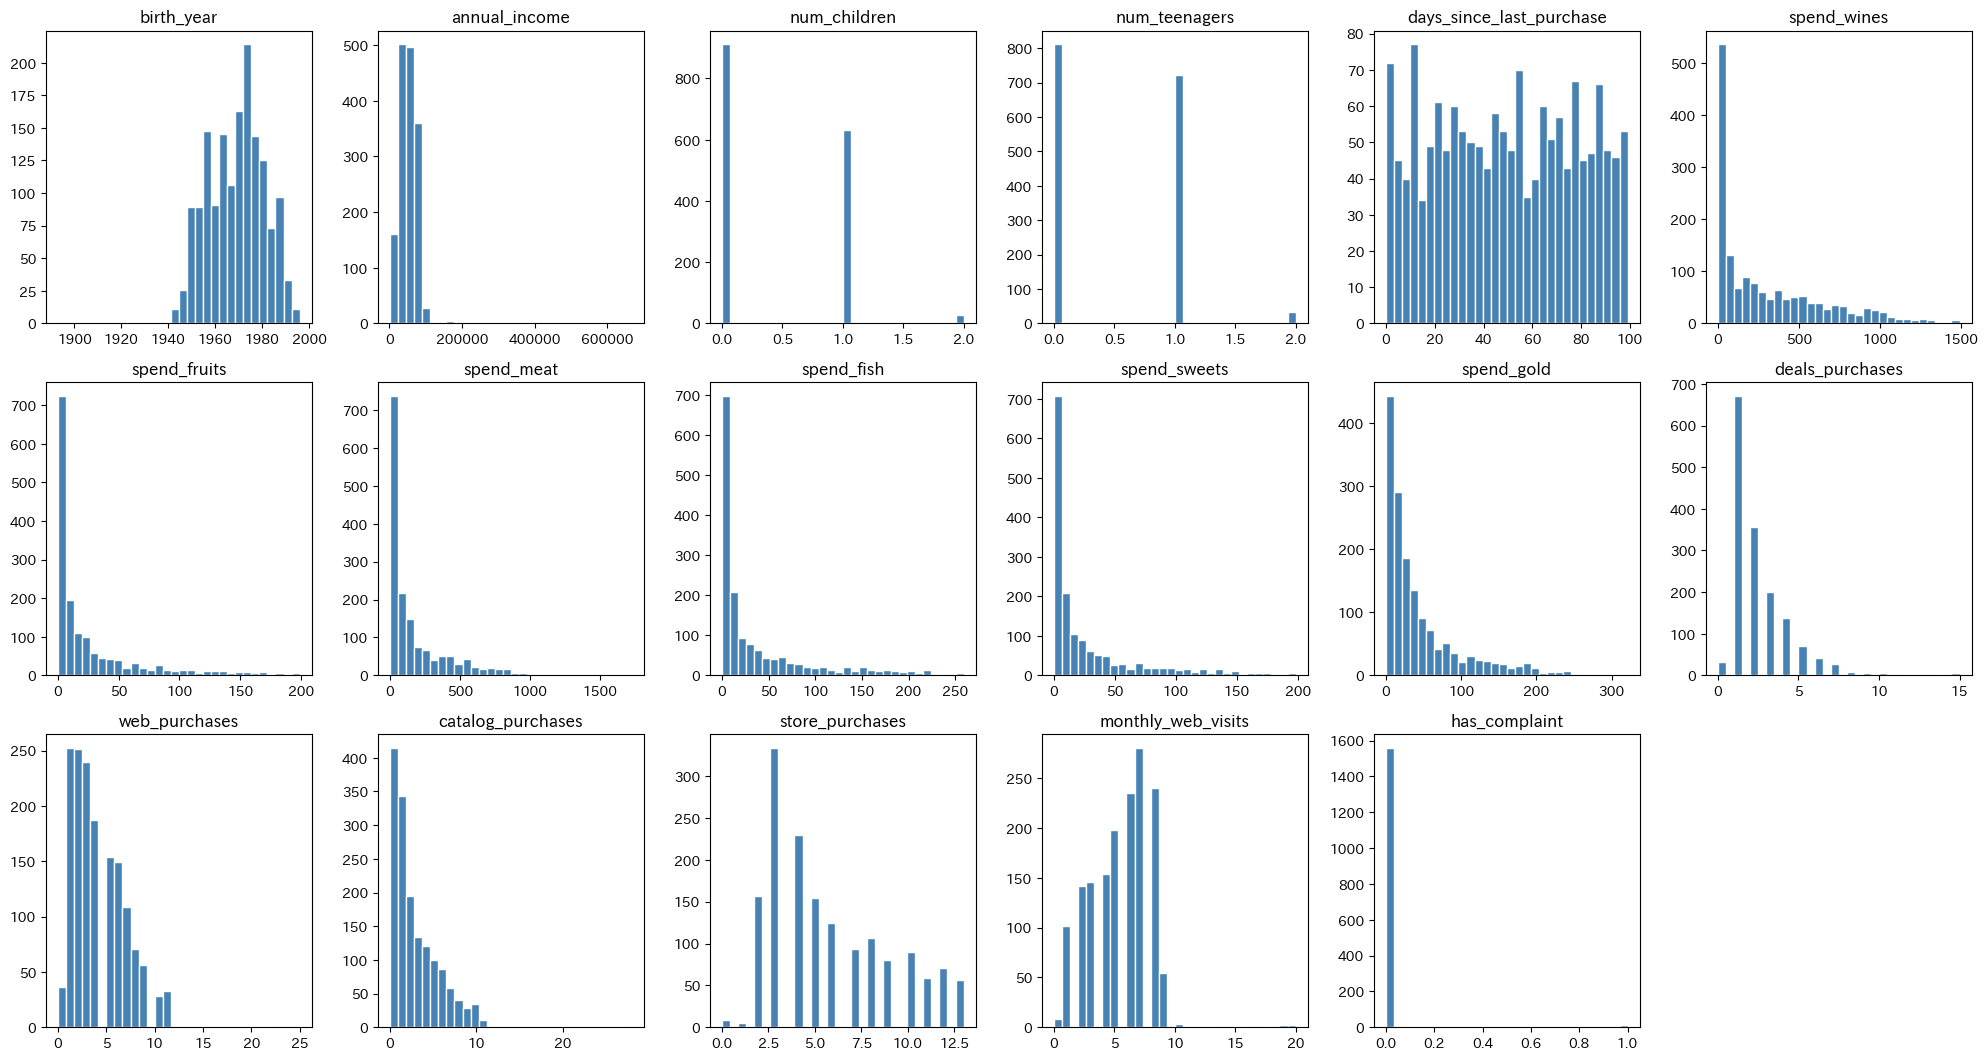

In [99]:
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = [c for c in numeric_cols if c not in ['customer_id', 'target']]

fig, axes = plt.subplots(4, 6, figsize=(20, 14))
axes = axes.flatten() #1次元に

for i, col in enumerate(numeric_cols):
  axes[i].hist(train[col].dropna(), bins=30, color='steelblue', edgecolor='white')
  axes[i].set_title(col)
for j in range(i + 1, len(axes)):
  axes[j].set_visible(False)
plt.tight_layout()
plt.show()


In [100]:
train['annual_income'].sort_values().tail()

,annual_income
1142,NaN
1174,NaN
1240,NaN
1416,NaN
1567,NaN


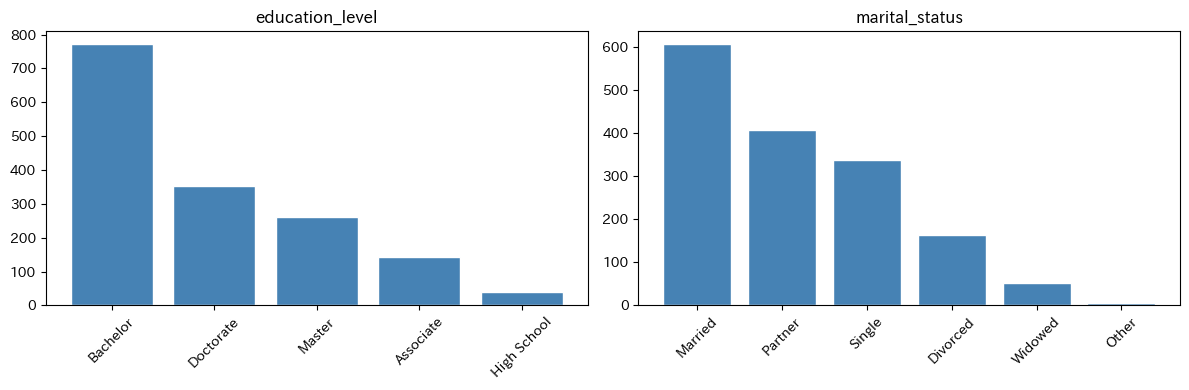

In [101]:
categorical_cols = ['education_level', 'marital_status']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
  counts = train[col].value_counts()
  axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='white')
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=45) #Matplotlibで「目盛り（tick）」や「目盛りラベル」のデザイン（文字の大きさ、色、向きなど）を調整するための専用メソッド

plt.tight_layout()
plt.show()

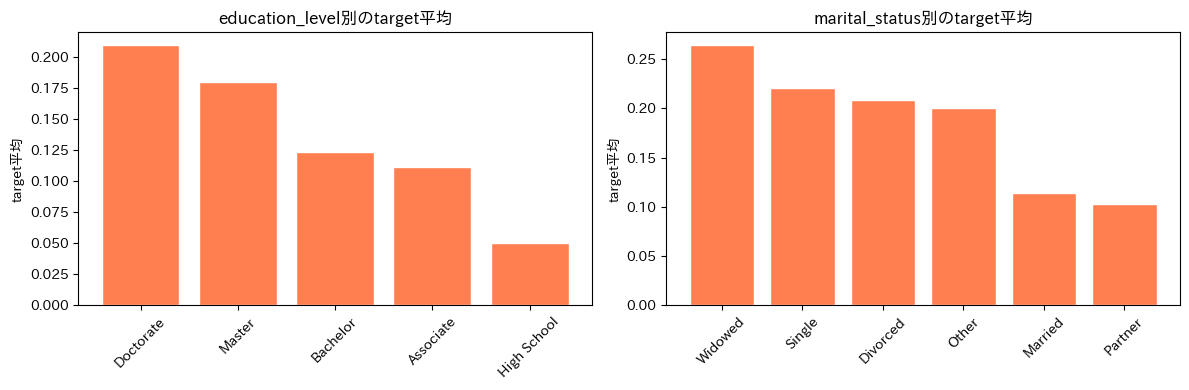

In [102]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(categorical_cols):
  target_mean = train.groupby(col)['target'].mean().sort_values(ascending=False)
  axes[i].bar(target_mean.index, target_mean.values, color='coral',edgecolor='white')
  axes[i].set_title(f'{col}別のtarget平均')
  axes[i].tick_params(axis='x', rotation=45)
  axes[i].set_ylabel('target平均')
plt.tight_layout()
plt.show()

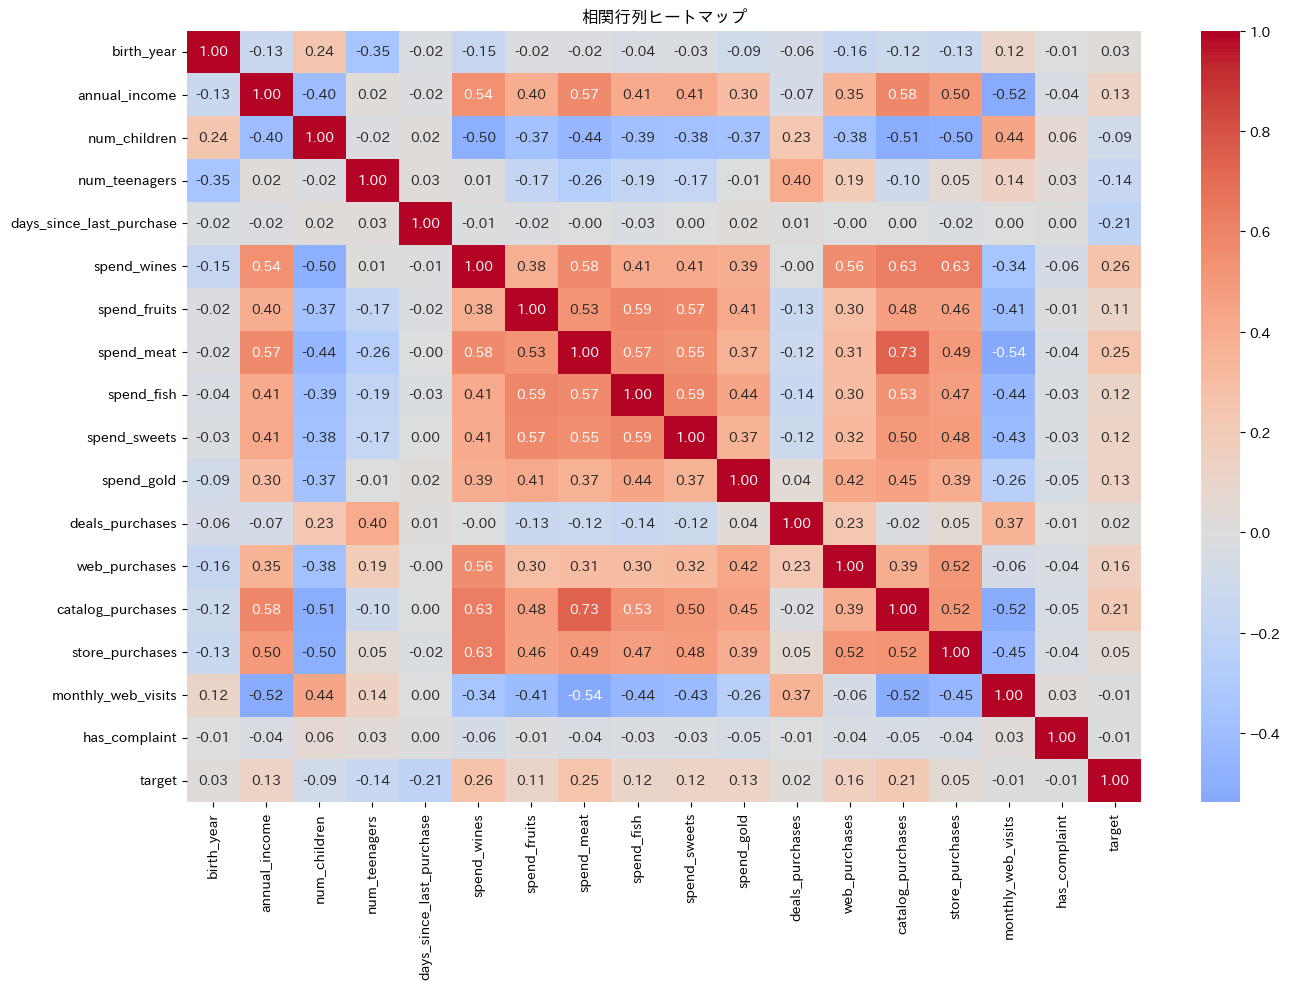

In [103]:
numeric_for_corr = train.select_dtypes(include=['number']).drop(columns=['customer_id'])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',center=0)
plt.title('相関行列ヒートマップ')
plt.tight_layout()
plt.show()

In [104]:
# 欠損値補完
median_income = train['annual_income'].median()
for df in [test, train]:
  df['annual_income'] = df['annual_income'].fillna(median_income)

In [105]:
# カテゴリカル変数をターゲットエンコーディング
import category_encoders as ce

cols_to_encode = ['education_level', 'marital_status']
te = ce.TargetEncoder(cols = cols_to_encode, smoothing=10)
train[cols_to_encode] = te.fit_transform(train[cols_to_encode], train['target'])
test[cols_to_encode] = te.transform(test[cols_to_encode])

In [106]:
# 'customer_id', 'registration_date'を削除(後から使い方を検討)
for df in [train, test]:
  df.drop(columns=['customer_id', 'registration_date'], inplace=True)
print('Train欠損:', train.isnull().sum().sum(), ' 列:', list(train.columns))

Train欠損: 0  列: ['birth_year', 'education_level', 'marital_status', 'annual_income', 'num_children', 'num_teenagers', 'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'has_complaint', 'target']


In [132]:
# 特徴量の生成,対数変換
# 対数変換に効果があるかは微妙
spend_cols = ['spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']
purchases_cols = ['web_purchases','catalog_purchases', 'store_purchases']
luxury_cols = ["spend_wines", "spend_gold", "spend_sweets"]
fresh_cols = ["spend_fruits", "spend_meat", "spend_fish"]


for df in [train, test]:
    df['age'] = 2024 - df['birth_year']  # 基準年は便宜上の固定値。大小関係が保てればよい
    df['total_spend'] = df[spend_cols].sum(axis=1)  # spend_* 6列の合計
    upper = df['annual_income'].quantile(0.99)
    df['income_clipped'] =  df['annual_income'].clip(upper=upper)
    df['luxury_ratio'] = df[luxury_cols].sum(axis=1) / df["total_spend"]
    df['fresh_ratio'] = df[fresh_cols].sum(axis=1) / df["total_spend"]
    df['total_purchases'] = df[purchases_cols].sum(axis=1)
    df['deal_sensitivity'] = df['deals_purchases'] / (df['total_purchases']+ 1e-5)

for spend in spend_cols:
  for df in [train, test]:
    df[f"{spend}_ratio"] = df[spend] / (df['total_spend'] + 1e-5)




df[]

    確認済み
    df['is_web_prefer'] = (df['web_purchases'] >= df['store_purchases']).astype(int)
    df['have_children'] = (df['num_children'] >= 1).astype(int)
    df['web_catalog_purchases'] = df[web_catalog_purchases].sum(axis=1)
    df['total_purchases'] = df[purchases_cols].sum(axis=1)
    df['total_spend_log'] = np.log1p(df['total_spend'])
    for spend in spend_cols:
  for df in [train, test]:
    df[f"{spend}_log"] = np.log1p(df[spend])

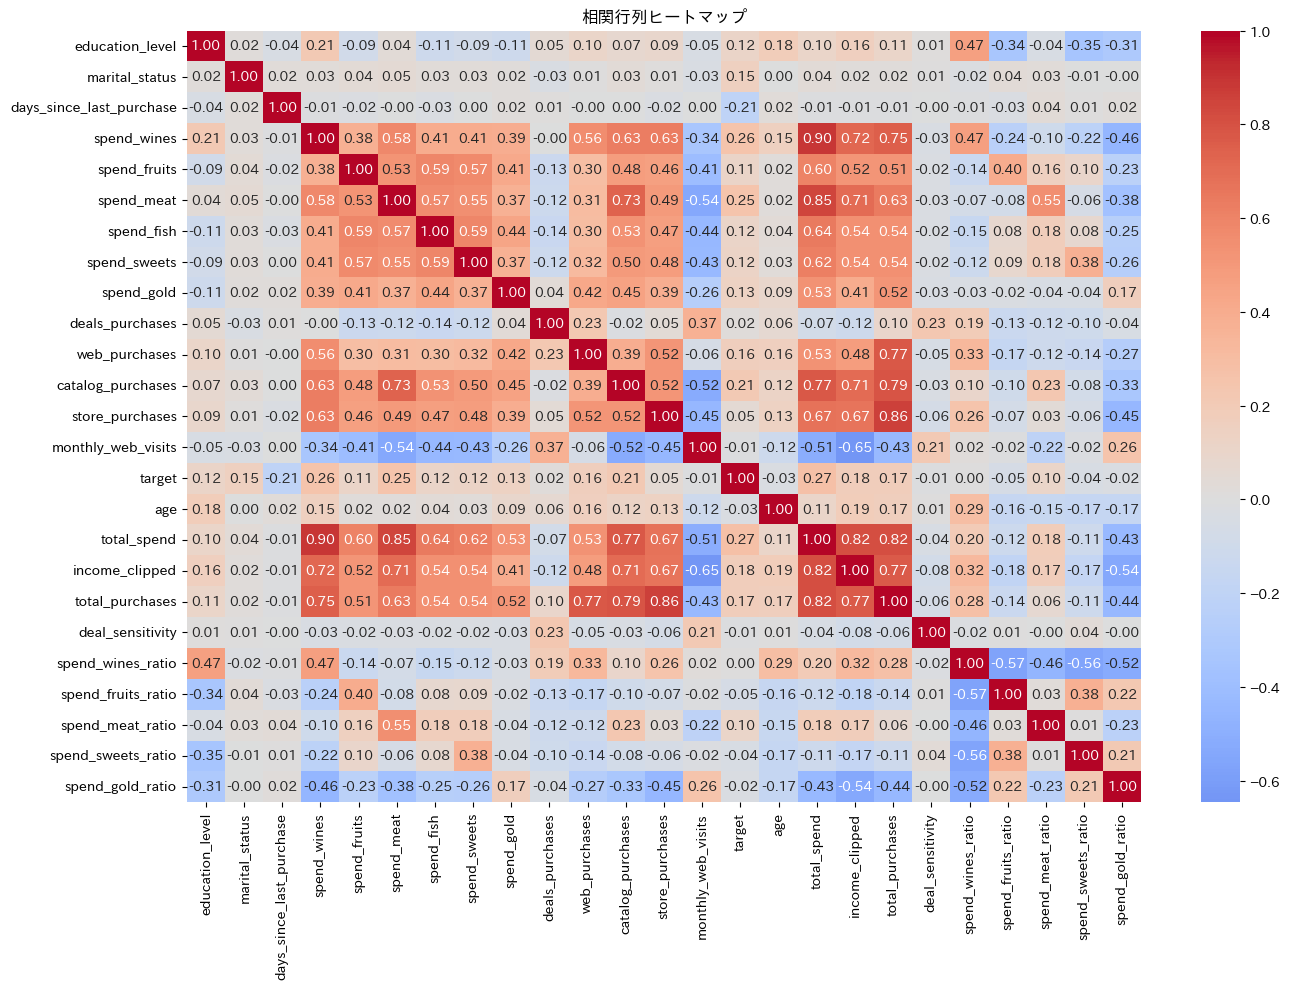

In [160]:
df1 = train.drop(columns=['birth_year', 'has_complaint', "annual_income", 'luxury_ratio', 'fresh_ratio', 'spend_fish_ratio', 'num_children', 'num_teenagers'])
numeric_for_corr = df1.select_dtypes(include=['number'])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm',center=0)
plt.title('相関行列ヒートマップ')
plt.tight_layout()
plt.show()

In [199]:
X = train.drop(columns=['target', 'birth_year', 'has_complaint', "annual_income", 'spend_fruits_ratio', 'spend_fish_ratio', 'spend_sweets_ratio', 'spend_gold_ratio'])
y = train['target']
X.columns


Index(['education_level', 'marital_status', 'num_children', 'num_teenagers',
       'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat',
       'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases',
       'web_purchases', 'catalog_purchases', 'store_purchases',
       'monthly_web_visits', 'age', 'total_spend', 'income_clipped',
       'luxury_ratio', 'fresh_ratio', 'total_purchases', 'deal_sensitivity',
       'spend_wines_ratio', 'spend_meat_ratio'],
      dtype='object')

In [110]:
def objective(trial, model_name, X, y):


    if model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'random_state': 42,
            'verbose': -1
        }
        model = LGBMClassifier(**params)

    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'random_state': 42,
            'eval_metric': 'auc'
        }
        model = XGBClassifier(**params)

    elif model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'random_state': 42
        }
        model = RandomForestClassifier(**params)

    else:
        raise ValueError("未対応のモデルです")


    # 交差検証を用いた評価ロジック
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []


    for tr_idx, va_idx in skf.split(X, y):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[va_idx], p))

    return np.mean(scores)

In [198]:

# 実行ブロック（モデルの切り替え設定）

# ここを 'LightGBM', 'XGBoost', 'RandomForest' に変えるだけで他のモデルを試せる
TARGET_MODEL = 'RandomForest'

print(f"=== {TARGET_MODEL} の最適化を開始 ===")
study = optuna.create_study(direction='maximize')

# lambda関数を使って、objective関数に model_name を渡す
study.optimize(lambda trial: objective(trial, TARGET_MODEL, X, y), n_trials=30)

print(f"Best AUC Score: {study.best_value:.4f}")

# 結果の抽出
best_params = study.best_trial.params
best_features = [col for col in X.columns if best_params.get(f'use_{col}') == True]
best_model_params = {k: v for k, v in best_params.items() if not k.startswith('use_')}

print("\n最適なハイパーパラメータ:")
print(best_model_params)

[I 2026-07-02 10:24:25,370] A new study created in memory with name: no-name-582919fd-59d1-4a2f-a783-4f4ce5ee8c56


=== RandomForest の最適化を開始 ===


[I 2026-07-02 10:24:32,791] Trial 0 finished with value: 0.8395956005449812 and parameters: {'n_estimators': 142, 'max_depth': 8, 'min_samples_split': 2}. Best is trial 0 with value: 0.8395956005449812.
[I 2026-07-02 10:24:35,415] Trial 1 finished with value: 0.8342433430810653 and parameters: {'n_estimators': 142, 'max_depth': 6, 'min_samples_split': 4}. Best is trial 0 with value: 0.8395956005449812.
[I 2026-07-02 10:24:38,571] Trial 2 finished with value: 0.8414197099250638 and parameters: {'n_estimators': 132, 'max_depth': 12, 'min_samples_split': 9}. Best is trial 2 with value: 0.8414197099250638.
[I 2026-07-02 10:24:41,443] Trial 3 finished with value: 0.7982697339342494 and parameters: {'n_estimators': 218, 'max_depth': 3, 'min_samples_split': 6}. Best is trial 2 with value: 0.8414197099250638.
[I 2026-07-02 10:24:48,619] Trial 4 finished with value: 0.8442775597851909 and parameters: {'n_estimators': 246, 'max_depth': 9, 'min_samples_split': 5}. Best is trial 4 with value: 0.84

Best AUC Score: 0.8487

最適なハイパーパラメータ:
{'n_estimators': 276, 'max_depth': 14, 'min_samples_split': 9}


0.8550

特徴量:

['education_level', 'marital_status', 'num_children', 'num_teenagers',
       'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat',
       'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases',
       'web_purchases', 'catalog_purchases', 'store_purchases',
       'monthly_web_visits', 'age', 'total_spend', 'income_clipped',
       'luxury_ratio', 'fresh_ratio', 'total_purchases', 'deal_sensitivity',
       'spend_wines_ratio', 'spend_meat_ratio']

LightGBM : Best AUC Score: 0.8545


最適なハイパーパラメータ:
{'n_estimators': 207, 'learning_rate': 0.03554401314855261, 'max_depth': 3}

XGBoost : Best AUC Score: 0.8511


最適なハイパーパラメータ:
{'n_estimators': 253, 'learning_rate': 0.024487856846403606, 'max_depth': 3}

RandomForest : Best AUC Score: 0.8487


最適なハイパーパラメータ:
{'n_estimators': 276, 'max_depth': 14, 'min_samples_split': 9}

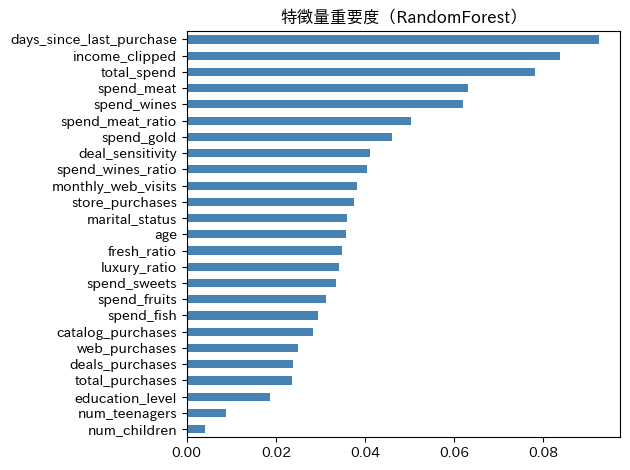

In [186]:
imp_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=11,
    min_samples_split=5,
    random_state=42
).fit(X, y)
importances = pd.Series(imp_model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='steelblue')
plt.title('特徴量重要度（RandomForest）')
plt.tight_layout()
plt.show()

In [113]:
# 追加箇所：アンサンブル・スタッキングの実装
from sklearn.ensemble import StackingClassifier


# 1. 各モデルのOptunaでの最適パラメータを設定（ベースモデルの定義）
best_lgb = LGBMClassifier(
    n_estimators=125,
    learning_rate=0.04601981669397727,
    max_depth=3,
    random_state=42,
    verbose=-1
)

best_xgb = XGBClassifier(
    n_estimators=139,
    learning_rate=0.05797819083747787,
    max_depth=3,
    random_state=42,
    eval_metric='auc'
)

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=11,
    min_samples_split=5,
    random_state=42
)

In [114]:


# 2. スタッキングで使用する特徴量の選定
# 各モデルで選ばれた特徴量が異なるため、ここでは最もスコアの良かったRandomForestの特徴量（10個）を基準にします
features_to_use = ['education_level', 'marital_status', 'num_children', 'num_teenagers',
       'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat',
       'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases',
       'web_purchases', 'catalog_purchases', 'store_purchases',
       'monthly_web_visits', 'age', 'income_clipped', 'total_spend_log']
X_stacked = X[features_to_use]

# 3. StackingClassifier の構築
# ステージ1: ベースモデルのリスト
base_estimators = [
    ('lgb', best_lgb),
    ('xgb', best_xgb),
    ('rf', best_rf)
]

# ステージ2: メタモデル（ベースモデルの予測値を統合するシンプルなモデル。通常はロジスティック回帰）
meta_estimator = LogisticRegression(random_state=42)

# スタッキングモデル本体の定義
stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_estimator,
    cv=5,          # 各ベースモデルのメタ特徴量（OOF予測）を作るための内部CV分割数
    n_jobs=-1,     # 並列処理
    passthrough=False # Falseの場合、メタモデルにはベースモデルの予測値のみが入力される（Trueだと元の特徴量も残る）
)

# 4. スタッキング全体の交差検証（CV）による評価
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
stacking_scores = []

for tr_idx, va_idx in skf.split(X_stacked, y):
    X_train, y_train = X_stacked.iloc[tr_idx], y.iloc[tr_idx]
    X_val, y_val = X_stacked.iloc[va_idx], y.iloc[va_idx]

    # 既存モデルと同様にクローンして学習
    model = clone(stacking_model)
    model.fit(X_train, y_train)

    # 予測確率の取得（target=1の確率）
    preds = model.predict_proba(X_val)[:, 1]
    stacking_scores.append(roc_auc_score(y_val, preds))

print(f"Stacking CV AUC Score: {np.mean(stacking_scores):.4f}")

KeyError: "['total_spend_log'] not in index"

In [ ]:
# 追加箇所：テストデータへの予測と提出ファイルの作成

print("=== 最終モデルの学習と予測を開始 ===")

# 1. 全学習データでスタッキングモデルを最終学習
# （CVでの評価が終わったので、手持ちの学習データを100%使って本番用のモデルを作ります）
stacking_model.fit(X_stacked, y)

# 2. テストデータの特徴量を、学習時と同じ10個に揃える
test_stacked = test[features_to_use]

# 3. テストデータに対する予測確率（target=1になる確率）を算出
test_pred = stacking_model.predict_proba(test_stacked)[:, 1]

# 4. 提出ファイルの作成
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission['target'] = test_pred

# ファイル名を 'submission_advanced.csv' から 'submission_stacking.csv' に変更して保存
submission.to_csv(PATH + 'submission_stacking.csv', index=False)

print('提出行数:', len(submission))
print('target範囲:', round(submission['target'].min(), 3), '〜', round(submission['target'].max(), 3))
submission.head()